<h2>Лабораторна робота №2</h2>
<h3>Моделювання функції з двох змінних засобами нечіткої математики</h3>

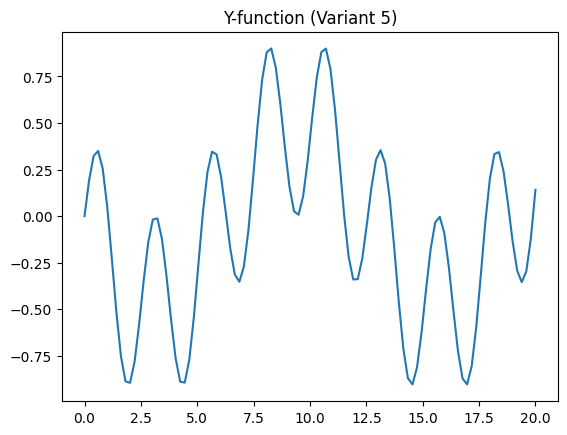

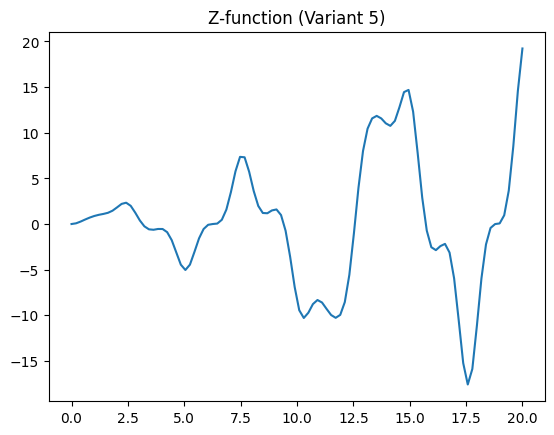

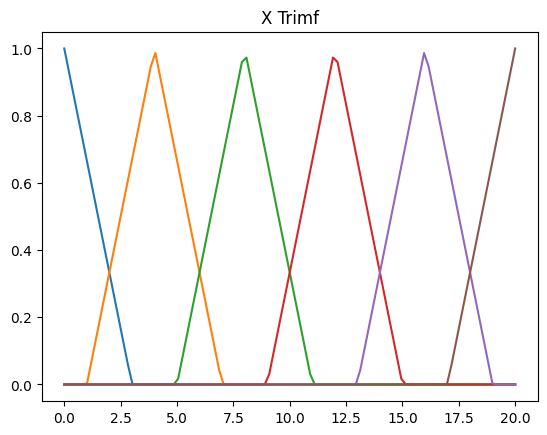

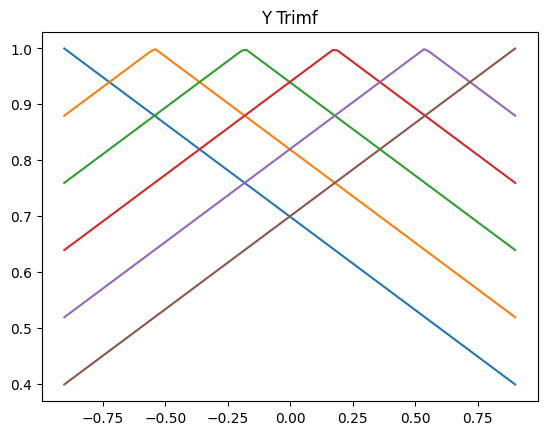

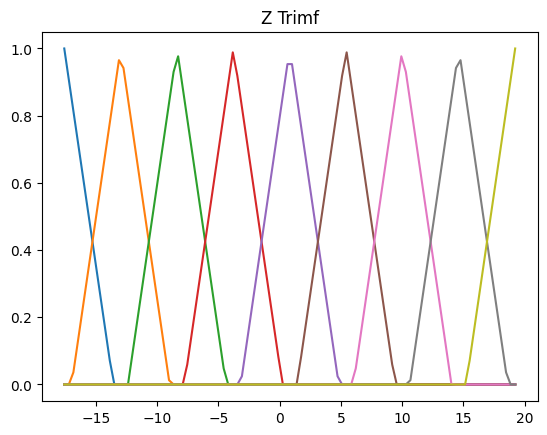

Таблиця значень
+-------+----+-------+------+--------+--------+-------+
| y\x   |  0 |  4    | 8    |  12    |  16    | 20    |
+-------+----+-------+------+--------+--------+-------+
| -0.9  | -0 |  0.18 | 5.81 | -11.94 |   9.19 |  4.88 |
+-------+----+-------+------+--------+--------+-------+
| -0.54 | -0 | -1.24 | 7.38 | -10.75 |   3.98 | 11.41 |
+-------+----+-------+------+--------+--------+-------+
| -0.18 | -0 | -2.5  | 7.99 |  -8.17 |  -1.75 | 16.48 |
+-------+----+-------+------+--------+--------+-------+
| 0.18  |  0 | -3.44 | 7.58 |  -4.54 |  -7.25 | 19.42 |
+-------+----+-------+------+--------+--------+-------+
| 0.54  |  0 | -3.94 | 6.19 |  -0.32 | -11.82 | 19.86 |
+-------+----+-------+------+--------+--------+-------+
| 0.9   |  0 | -3.93 | 4.01 |   3.93 | -14.87 | 17.74 |
+-------+----+-------+------+--------+--------+-------+

Таблиця з назвами функцій
+-----+-----+-----+-----+-----+-----+-----+
| y\x | mx1 | mx2 | mx3 | mx4 | mx5 | mx6 |
+-----+-----+-----+-----+----

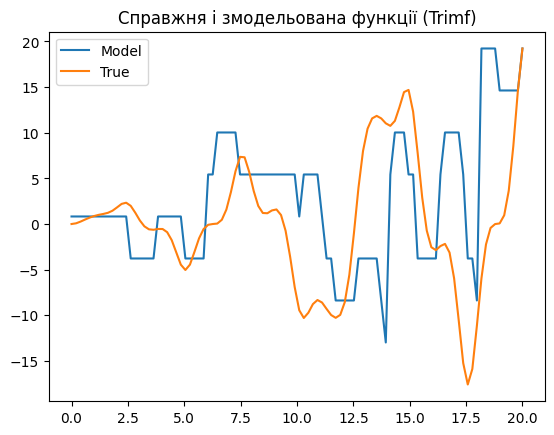


Mean Squared Error (MSE) = 86.20070982685006
Mean Absolute Error (MAE) = 6.802099357595987


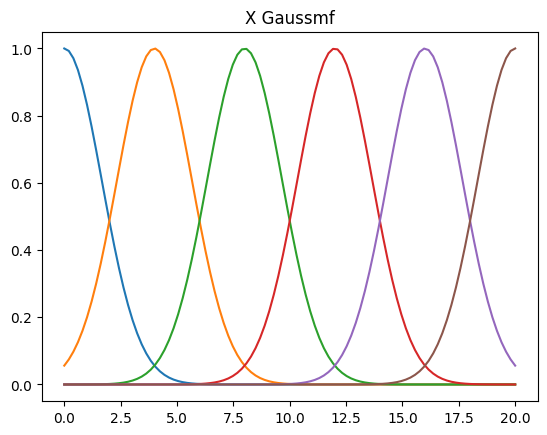

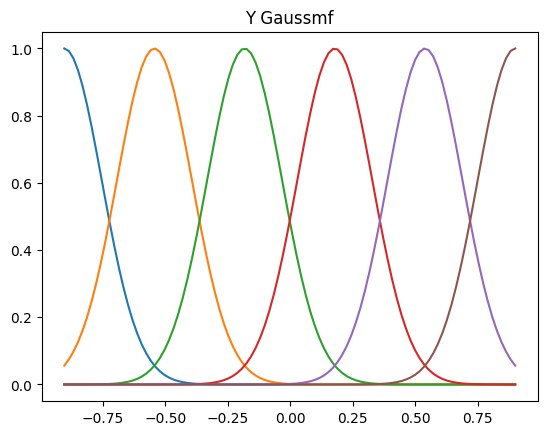

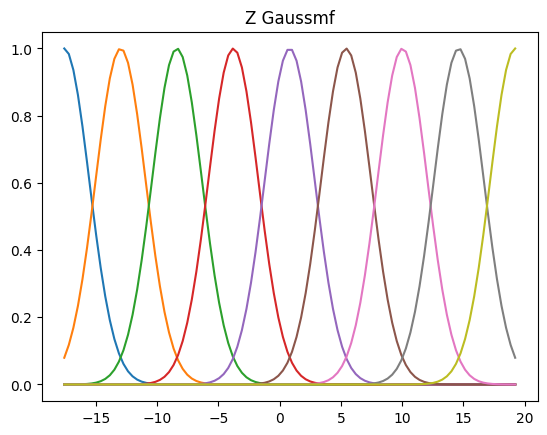

Таблиця значень
+-------+----+-------+------+--------+--------+-------+
| y\x   |  0 |  4    | 8    |  12    |  16    | 20    |
+-------+----+-------+------+--------+--------+-------+
| -0.9  | -0 |  0.18 | 5.81 | -11.94 |   9.19 |  4.88 |
+-------+----+-------+------+--------+--------+-------+
| -0.54 | -0 | -1.24 | 7.38 | -10.75 |   3.98 | 11.41 |
+-------+----+-------+------+--------+--------+-------+
| -0.18 | -0 | -2.5  | 7.99 |  -8.17 |  -1.75 | 16.48 |
+-------+----+-------+------+--------+--------+-------+
| 0.18  |  0 | -3.44 | 7.58 |  -4.54 |  -7.25 | 19.42 |
+-------+----+-------+------+--------+--------+-------+
| 0.54  |  0 | -3.94 | 6.19 |  -0.32 | -11.82 | 19.86 |
+-------+----+-------+------+--------+--------+-------+
| 0.9   |  0 | -3.93 | 4.01 |   3.93 | -14.87 | 17.74 |
+-------+----+-------+------+--------+--------+-------+

Таблиця з назвами функцій
+--------------+--------------+--------------+--------------+--------------+--------------+--------------+
| y\x     

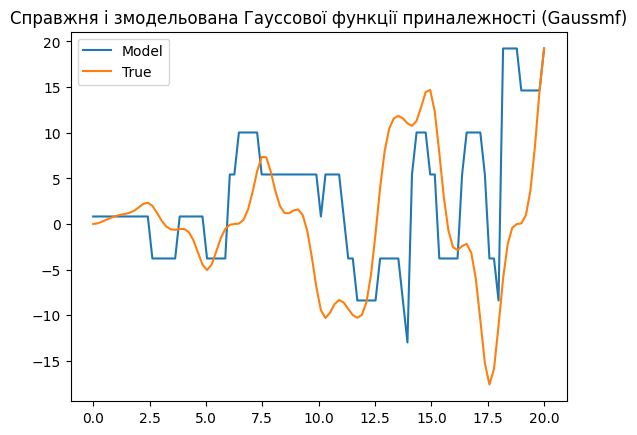


MSE (Gaussian) = 86.20070982685006

MAE (Gaussian) = 6.802099357595987


In [3]:
import numpy as np # Імпорт бібліотеки NumPy для роботи з масивами та математичними операціями
import matplotlib.pyplot as plt # Імпорт бібліотеки Matplotlib для побудови графіків
import skfuzzy as fuzz # Імпорт бібліотеки scikit-fuzzy для роботи з нечіткою логікою
from tabulate import tabulate # Імпорт функції tabulate для виведення таблиць у консоль у зручному вигляді
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Імпорт функцій для обчислення середньоквадратичної та середньої абсолютної похибок

# 1. Імпортуємо модулі та розраховуємо еталонні значення функцій
x_values = np.linspace(0, 20, 100) # Створюється 100 рівномірних точок у діапазоні від 0 до 20

# Варіант 5: y = sin|x| * cos(3x/2)
y_values = np.sin(np.abs(x_values)) * np.cos(3 * x_values / 2) 
# Обчислюється значення функції y для кожного x відповідно до формули варіанту

# Варіант 5: z = x * sin(x + y)
z_values = x_values * np.sin(x_values + y_values)
# Обчислюється значення функції z, використовуючи x та відповідні значення y

plt.plot(x_values, y_values) # Побудова графіку залежності y від x
plt.title("Y-function (Variant 5)") # Надається назву графіку функції y
plt.show() # Зображується графік

plt.plot(x_values, z_values) # Побудова графіку залежності z від x
plt.title("Z-function (Variant 5)") # Надається назву графіку функції z
plt.show() # Зображується графік

# 2. Створюємо функції приналежності (Трикутні)
x_means = np.linspace(min(x_values), max(x_values), 6)
# Визначається 6 центрів трикутних функцій приналежності для змінної x
y_means = np.linspace(min(y_values), max(y_values), 6)
# Визначається 6 центрів трикутних функцій приналежності для змінної y
z_means = np.linspace(min(z_values), max(z_values), 9)
# Визначається 9 центрів функцій приналежності для вихідної змінної z

# Допоміжні функції
# Оголошується функція calculate_trimf для обчислення трикутної функції приналежності
# Якщо x знаходиться на зростаючій частині трикутника a <= x < b — обчислює значення приналежності (x - a)/(b - a)
# Якщо x знаходиться на спадаючій частині трикутника b <= x <= c — обчислює значення приналежності (c - x)/(c - b)
# Якщо x поза межами трикутника — ступінь приналежності дорівнює 0
def calculate_trimf(x, a, b, c):
    if a <= x < b:
        return (x - a) / (b - a)
    elif b <= x <= c:
        return (c - x) / (c - b)
    else:
        return 0

# Функція для визначення functionCompare, до якої функції приналежності значення належить найбільше
# Ініціалізується максимальне значення функції приналежності: best_func_value = -float("inf")
# Ініціалізується індекс найкращої функції: best_index = -1
# Проходить по всіх центрах функцій приналежності: for index, mean in enumerate(means):
# Обчислюється значення трикутної функції приналежності для поточного центру:  
# ff = calculate_trimf(value, mean - diff, mean, mean + diff)
# Якщо знайдено більше значення — оновлюється максимум і запам’ятовує індекс:
# if ff > best_func_value:
#     best_func_value = ff
#     best_index = index
# Повертається індекс функції з найбільшою приналежністю: return best_index
def functionCompare(value, means, diff):
    best_func_value = -float("inf")
    best_index = -1
    for index, mean in enumerate(means):
        ff = calculate_trimf(value, mean - diff, mean, mean + diff)
        if ff > best_func_value:
            best_func_value = ff
            best_index = index
    return best_index

# Візуалізація X Trimf
mx = [fuzz.trimf(x_values, [x_means[i] - 3, x_means[i], x_means[i] + 3]) for i in range(6)]
# Створюється список трикутних функцій приналежності для змінної x

# Побудова графіків всіх функцій приналежності x
for i in range(6):
    plt.plot(x_values, mx[i])
plt.title("X Trimf") # Надається назву графіку
plt.show() # Зображується графік

# Візуалізація Y Trimf
my = [fuzz.trimf(np.linspace(min(y_values), max(y_values), 100), [y_means[i] - 3, y_means[i], y_means[i] + 3]) 
      for i in range (6) ]

# Побудова графіків всіх функцій приналежності y
for i in range(6):
    plt.plot(np.linspace(min(y_values), max(y_values), 100), my[i])
plt.title("Y Trimf") # Надається назву графіку
plt.show() # Зображується графік

# Візуалізація Z Trimf
mz = [fuzz.trimf(np.linspace(min(z_values), max(z_values), 100), [z_means[i] - 4, z_means[i], z_means[i] + 4]) 
      for i in range (9) ]

# Побудова графіків всіх функцій приналежності z
for i in range(9):
    plt.plot(np.linspace(min(z_values), max(z_values), 100), mz[i])
plt.title("Z Trimf") # Надається назву графіку
plt.show() # Зображується графік

# 3. Таблиці значень та імен функцій
print("Таблиця значень") # Виводить заголовок таблиці значень

# Формується перший рядок таблиці зі значеннями x
table_vals = [["y\\x"] + [str(round(x, 2)) for x in x_means]] 

# Проходить по всіх значеннях y: for y_val in y_means:
# Створюється рядок таблиці, починаючи зі значення y: row = [round(y_val, 2)]
# Обчислюється z для пари (x, y):
# for x_val in x_means:
#     z = x_val * np.sin(x_val + y_val)
# Додається значення z до рядка: row.append(round(z, 2))
# Додається рядок до таблиці: table_vals.append(row) 
# Виводиться таблицю у вигляді сітки: print(tabulate(table_vals, tablefmt="grid"))
for y_val in y_means:
    row = [round(y_val, 2)]
    for x_val in x_means:
        z = x_val * np.sin(x_val + y_val) # Варіант 5
        row.append(round(z, 2))
    table_vals.append(row)
print(tabulate(table_vals, tablefmt="grid"))

# Створюється словник для збереження правил нечіткого виводу
rules = {}

print("\nТаблиця з назвами функцій") # Виводить заголовок таблиці з назвами функцій

# Формує перший рядок таблиці: перший елемент — "y\x", 
# далі назви функцій приналежності змінної x (mx1, mx2, …, mx6)
table_names = [["y\\x"] + ["mx" + str(i+1) for i in range(6)]]

# Запускається цикл за всіма функціями приналежності змінної y: for i in range(6):
# Створюється новий рядок таблиці, що починається з назви функції y (my1, my2, …): 
# row = ["my" + str(i + 1)]
# Запускається внутрішній цикл за всіма функціями приналежності змінної x: for j in range(6):
# Обчислюється значення вихідної змінної z для комбінації центрів x та y відповідно до формули варіанту: 
# z = x_means[j] * np.sin(x_means[j] + y_means[i])
# Визначається, до якої функції приналежності z належить найбільше 
# (diff=15 задає ширину трикутних функцій для змінної z):
# best_func = functionCompare(z, z_means, diff=15)
# Додається до таблиці назву функції приналежності вихідної змінної (mz1, mz2, …): 
# row.append("mz" + str(best_func + 1))
# Зберігається правило у словник: для пари (x_j, y_i) зберігається відповідна функція z:
# rules[(j, i)] = best_func
# Додається сформований рядок до таблиці з назвами функцій: table_names.append(row)
# Виводиться таблицю назв функцій у вигляді сітки: print(tabulate(table_names, tablefmt="grid"))

for i in range(6):
    row = ["my" + str(i + 1)]
    for j in range(6):
        z = x_means[j] * np.sin(x_means[j] + y_means[i])
        best_func = functionCompare(z, z_means, diff=15) # diff підібрано для Z
        row.append("mz" + str(best_func + 1))
        rules[(j, i)] = best_func
    table_names.append(row)
print(tabulate(table_names, tablefmt="grid"))

# 4. Виведення правил
print("\nRules:") # Виведення заголовку списку правил нечіткої логіки, тобто "Rules"

# Проходить по всіх збережених правилах у словник: for rule in rules.keys():
# Виводиться правило у текстовому вигляді: IF x належить mx AND y належить my THEN z належить mf
for rule in rules.keys():
    print(f"if (x is mx{rule[0] + 1}) and (y is my{rule[1] + 1}) then (z is mz{rules[rule] + 1})")

# 5. Побудова моделі та виведення похибок
z_output = [] # Створює порожній список для змодельованих значень z

# Проходить по всіх значеннях змінної x: for x_val in x_values:
# Отримуємо y для поточного x згідно формули варіанту: 
# current_y = np.sin(np.abs(x_val)) * np.cos(3 * x_val / 2)
# Визначається, до якої функції приналежності x належить найбільше: 
# best_x_func = functionCompare(x_val, x_means, diff=4)
# Визначається, до якої функції приналежності y належить найбільше: 
# best_y_func = functionCompare(current_y, y_means, diff=0.5)
# За знайденими x та y вибирається відповідне правило для z: 
# best_z_func = rules[(best_x_func, best_y_func)]
# Додається центр відповідної функції z до вихідного масиву моделі: 
# z_output.append(z_means[best_z_func])
for x_val in x_values:    
    current_y = np.sin(np.abs(x_val)) * np.cos(3 * x_val / 2)    
    best_x_func = functionCompare(x_val, x_means, diff=4)
    best_y_func = functionCompare(current_y, y_means, diff=0.5)
    best_z_func = rules[(best_x_func, best_y_func)]
    z_output.append(z_means[best_z_func])

plt.plot(x_values, z_output, label="Model") # Побудова графіку змодельованої функції z
plt.plot(x_values, z_values, label="True") # Побудова графіку справжньої (еталонної) функції z
plt.title("Справжня і змодельована функції (Trimf)") # Надається назву графіку
plt.legend() # Відображається маленьке віконце на графіку, де написано, що означають лінії на графіку
plt.show() # Зображується графік

# Обчислюється середньоквадратична похибка (MSE) між моделлю та еталоном
mse = mean_squared_error(z_values, z_output) 
mae = mean_absolute_error(z_values, z_output) # Обчислюється середня абсолютна похибка (MAE)
print(f"\nMean Squared Error (MSE) = {mse}") # Виводиться значення похибок у консоль (MSE)
print(f"Mean Absolute Error (MAE) = {mae}") # Виводиться значення похибок у консоль (MAE)

# 6. Повторення з Гауссовою функцією приналежності
# Обчислюється стандартне відхилення для гаусових функцій змінної x
x_sigma = (max(x_values) - min(x_values)) / 6 / 2 
y_sigma = (max(y_values) - min(y_values)) / 6 / 2 # Обчислюється стандартне відхилення для змінної y
z_sigma = (max(z_values) - min(z_values)) / 9 / 2 # Обчислює стандартне відхилення для змінної z

# Приклад заміни функції calculate_trimf на гауссову логіку у порівнянні
# Оголошується функцію functionCompareGauss для вибору найкращої гаусової функції приналежності: 
# def functionCompareGauss(value, means, sigma):
# Ініціалізується максимальне значення та індекс:
#  best_func_value = -float("inf")
#  best_index = -1
# Проходить по всіх центрах гаусових функцій: for index, mean in enumerate(means):
# Обчислюється значення гаусової функції приналежності в точці: 
# ff = np.exp(-((value - mean)**2) / (2 * sigma**2))
# Зберігається функцію з найбільшим значенням належності: 
#  if ff > best_func_value:
#      best_func_value = ff
#      best_index = index
# Повертається індекс найкращої гаусової функції, тобто з набйльшим значенням: return best_index#
def functionCompareGauss(value, means, sigma):
    best_func_value = -float("inf")
    best_index = -1
    for index, mean in enumerate(means):
        ff = np.exp(-((value - mean)**2) / (2 * sigma**2))
        if ff > best_func_value:
            best_func_value = ff
            best_index = index
    return best_index

# Візуалізація X Gaussmf
mx_gaussian = [fuzz.gaussmf(x_values, x_means[i], x_sigma) for i in range(6)]
# Створюється список трикутних функцій приналежності для змінної x

# Побудова графіків всіх Гауссових функцій приналежності x
for i in range(6):
    plt.plot(x_values, mx_gaussian[i])
plt.title("X Gaussmf") # Надається назву графіку
plt.show() # Зображується графік

# Візуалізація Y Gaussmf
my_gaussian = [fuzz.gaussmf(np.linspace(min(y_values), max(y_values), 100), y_means[i], y_sigma) 
               for i in range (6)]

# Побудова графіків всіх Гауссових функцій приналежності y
for i in range(6):
    plt.plot(np.linspace(min(y_values), max(y_values), 100), my_gaussian[i])
plt.title("Y Gaussmf") # Надається назву графіку
plt.show() # Зображується графік

# Візуалізація Z Gaussmf
mz_gaussian = [fuzz.gaussmf(np.linspace(min(z_values), max(z_values), 100), z_means[i], z_sigma) 
               for i in range (9)]

# Побудова графіків всіх Гауссових функцій приналежності z
for i in range(9):
    plt.plot(np.linspace(min(z_values), max(z_values), 100), mz_gaussian[i])
plt.title("Z Gaussmf") # Надається назву графіку
plt.show() # Зображується графік

# Таблиці значень та імен для Гауссових функцій приналежності
print("Таблиця значень") # Виводить заголовок таблиці значень

# Формується перший рядок таблиці зі значеннями x
table_vals = [["y\\x"] + [str(round(x, 2)) for x in x_means]] 

# Проходить по всіх значеннях y: for y_val in y_means:
# Створюється рядок таблиці, починаючи зі значення y: row = [round(y_val, 2)]
# Обчислюється z для пари (x, y):
# for x_val in x_means:
#     z = x_val * np.sin(x_val + y_val)
# Додається значення z до рядка: row.append(round(z, 2))
# Додається рядок до таблиці: table_vals.append(row) 
# Виводиться таблицю у вигляді сітки: print(tabulate(table_vals, tablefmt="grid"))
for y_val in y_means:
    row = [round(y_val, 2)]
    for x_val in x_means:
        z = x_val * np.sin(x_val + y_val) # Варіант 5
        row.append(round(z, 2))
    table_vals.append(row)
print(tabulate(table_vals, tablefmt="grid"))

# Створюється словник для збереження правил нечіткого виводу
rules = {}

print("\nТаблиця з назвами функцій") # Виводить заголовок таблиці з назвами функцій

# Формує перший рядок таблиці: перший елемент — "y\x", 
# далі назви функцій приналежності змінної x (_mx_gaussian1, mx_gaussian2, …, mx_gaussian6)
table_names = [["y\\x"] + ["mx_gaussian" + str(i+1) for i in range(6)]]

# Запускається цикл за всіма функціями приналежності змінної y: for i in range(6):
# Створюється новий рядок таблиці, що починається з назви функції y (my_gaussian1, my_gaussian2, …): 
# row = ["my_gaussian" + str(i + 1)]
# Запускається внутрішній цикл за всіма функціями приналежності змінної x: for j in range(6):
# Обчислюється значення вихідної змінної z для комбінації центрів x та y відповідно до формули варіанту: 
# z = x_means[j] * np.sin(x_means[j] + y_means[i])
# Визначається, до якої функції приналежності z належить найбільше 
# (diff=15 задає ширину трикутних функцій для змінної z):
# best_func = functionCompare(z, z_means, diff=15)
# Додається до таблиці назву функції приналежності вихідної змінної (mz_gaussian1, mz_gaussian2, …): 
# row.append("mz_gaussian" + str(best_func + 1))
# Зберігається правило у словник: для пари (x_j, y_i) зберігається відповідна функція z:
# rules[(j, i)] = best_func
# Додається сформований рядок до таблиці з назвами функцій: table_names.append(row)
# Виводиться таблицю назв функцій у вигляді сітки: print(tabulate(table_names, tablefmt="grid"))

for i in range(6):
    row = ["my_gaussian" + str(i + 1)]
    for j in range(6):
        z = x_means[j] * np.sin(x_means[j] + y_means[i])
        best_func = functionCompare(z, z_means, diff=15) # diff підібрано для Z
        row.append("mz_gaussian" + str(best_func + 1))
        rules[(j, i)] = best_func
    table_names.append(row)
print(tabulate(table_names, tablefmt="grid"))

# Виведення правил для Гауссових функцій приналежності
print("\nRules:") # Виведення заголовку списку правил нечіткої логіки, тобто "Rules"

# Проходить по всіх збережених правилах у словник: for rule in rules.keys():
# Виводиться правило у текстовому вигляді: IF x належить mx AND y належить my THEN z належить mz
for rule in rules.keys():
    print(f"if (x is mx_gaussian{rule[0] + 1}) and (y is my_gaussian{rule[1] + 1}) then (z is mz_gaussian{rules[rule] + 1})")

z_output_gauss = [] # Створюється порожній список для результатів моделі з гаусовими функціями

# Проходить по всіх значеннях x: for x_val in x_values:
# Обчислюється відповідне значення y: current_y = np.sin(np.abs(x_val)) * np.cos(3 * x_val / 2)
# Визначається найкращу гауссову функцію для x: bx = functionCompareGauss(x_val, x_means, x_sigma)
# Визначається найкращу гауссову функцію для y: by = functionCompareGauss(current_y, y_means, y_sigma)
# Отримується правило для z: bz = rules[(bx, by)]
# Додається змодельоване значення z: z_output_gauss.append(z_means[bz])
for x_val in x_values:
    current_y = np.sin(np.abs(x_val)) * np.cos(3 * x_val / 2) # Варіант 5: y = sin|x| * cos(3x/2)
    bx = functionCompareGauss(x_val, x_means, x_sigma)
    by = functionCompareGauss(current_y, y_means, y_sigma)
    bz = rules[(bx, by)]
    z_output_gauss.append(z_means[bz])

# Побудова графіку змодельованої Гауссової функції приналежності z
plt.plot(x_values, z_output_gauss, label="Model") 
# Побудова графіку справжньої (еталонної) Гауссоої функції приналежності z
plt.plot(x_values, z_values, label="True") 
plt.title("Справжня і змодельована Гауссової функції приналежності (Gaussmf)") # Надається назву графіку
plt.legend() # Відображається маленьке віконце на графіку, де написано, що означають лінії на графіку
plt.show() # Зображується графік


# Обчислюється та виводиться (MSE) для моделі з гаусовими функціями приналежності
print(f"\nMSE (Gaussian) = {mean_squared_error(z_values, z_output_gauss)}")
# Обчислюється та виводиться (MAE) для моделі з гаусовими функціями приналежності
print(f"\nMAE (Gaussian) = {mean_absolute_error(z_values, z_output_gauss)}")

# ==============================================================================
# КОНТРОЛЬНІ ЗАПИТАННЯ:
# ==============================================================================
# 1. Що таке нечітка змінна і чим вона відрізняється від звичайної (чіткої) змінної?
#    Нечітка змінна описується не числом, а функцією приналежності, що дозволяє 
#    елементу належати до множини частково (від 0 до 1).
#
# 2. Які складові має нечітка змінна?
#    Назва, універсум (базова область), терм-множина та функції приналежності.
#
# 3. Що таке терм-множина та яке її призначення?
#    Це набір лінгвістичних значень (напр. "малий", "середній"), якими описується змінна.
#
# 4. Наведіть приклад нечіткої змінної з повсякденного життя.
#    "Вік людини" з термами: дитина, підліток, дорослий, літня людина.
#
# 5. Яким чином описуються значення нечіткої змінної?
#    За допомогою функцій приналежності (трикутні, трапецієподібні, Гаусові тощо).
#
# 6. Що таке лінгвістична змінна?
#    Змінна, значеннями якої є слова або словосполучення природної мови.
#
# 7. Яка різниця між нечіткою та лінгвістичною змінною?
#    Лінгвістична змінна — це вищий рівень абстракції, що використовує нечіткі 
#    змінні як математичну основу для мовних термів.
#
# 8. Що таке система нечіткого виводу?
#    Це алгоритм отримання нечітких висновків на основі вхідних даних та бази правил.
#
# 9. Які основні етапи роботи системи нечіткого виводу?
#    Фазифікація, база знань (правила), блок рішень, дефазифікація.
#
# 10. Які етапи входять у процес фазифікації?
#     Перетворення чітких значень входу у ступені приналежності до нечітких термів.
#
# 11. Що таке база правил і як вона формується?
#     Це набір логічних умов "ЯКЩО вхід..., ТО вихід...". Формується експертом або за моделлю.
#
# 12. Яка роль механізму нечіткого логічного висновку?
#     Обробка нечітких даних згідно з правилами для отримання нечіткого результату на виході.
#
# 13. Що таке дефазифікація і для чого вона потрібна?
#     Перетворення нечіткого висновку (множини) у чітке число для керування об'єктом.
#
# 14. Які найбільш поширені методи дефазифікації?
#     Метод центру ваги (centroid) та метод найбільшого максимуму.
#
# 15. У яких практичних сферах найчастіше застосовуються системи нечіткого виводу?
#     Автоматизація (пральні машини, ABS), робототехніка, економічне прогнозування.
# ==============================================================================

<h2>Виконала студентка групи ЗПІ-зп41  <br>Грищенко Юлія</h2>
